# Project Overview

Project ini bertujuan untuk menganalisis dan memprediksi **rating restoran** berdasarkan data konsumen, restoran, cuisine, pembayaran, parkir, dan jam operasional.

Dataset terdiri dari beberapa file CSV yang saling terhubung melalui:

```text
userID
placeID
```

## Goal

Membangun model machine learning untuk memprediksi rating restoran dan memahami faktor yang paling berpengaruh terhadap rating.

## Main Task

```text
Regression: memprediksi nilai rating restoran
```

Optional task:

```text
Classification: mengelompokkan rating menjadi low, medium, high
Recommendation: rekomendasi restoran berdasarkan user dan rating
```

## Algorithm Plan

Model awal:

```text
1. Linear Regression
2. Ridge Regression
```

Model optimasi:

```text
3. Random Forest Regressor
4. XGBoost / Gradient Boosting Regressor
```

## Topics

```text
EDA
Data Cleaning
Data Integration
Feature Engineering
Kendall Tau
Point-Biserial Correlation
IQR Outlier Detection
K-Fold Cross Validation
Bias-Variance Analysis
Hyperparameter Tuning
Model Interpretation
```

## Workflow

```mermaid
flowchart TD
    A[Load CSV Files] --> B[Dataset Understanding]
    B --> C[Data Cleaning]
    C --> D[Data Integration]
    D --> E[EDA]
    E --> F[Feature Engineering]
    F --> G[Preprocessing]
    G --> H[Model Training]
    H --> I[Evaluation]
    I --> J[Hyperparameter Tuning]
    J --> K[Model Interpretation]
    K --> L[Conclusion]
```

## Expected Output

```text
1. Dataset gabungan yang bersih
2. Analisis faktor yang memengaruhi rating
3. Perbandingan 4 algoritma
4. Evaluasi model terbaik
5. Kesimpulan dan insight
```


## Dataset Understanding

### Init Dataset

In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd

DATASET = "uciml/restaurant-data-with-consumer-ratings"

files = [
    "rating_final.csv",
    "geoplaces2.csv",
    "userprofile.csv",
    "usercuisine.csv",
    "userpayment.csv",
    "chefmozcuisine.csv",
    "chefmozhours4.csv",
    "chefmozparking.csv",
    "chefmozaccepts.csv",
]

dfs = {}

for file_path in files:
    name = file_path.replace(".csv", "")

    try:
        dfs[name] = kagglehub.load_dataset(
            KaggleDatasetAdapter.PANDAS,
            DATASET,
            file_path
        )
    except UnicodeDecodeError:
        dfs[name] = kagglehub.load_dataset(
            KaggleDatasetAdapter.PANDAS,
            DATASET,
            file_path,
            pandas_kwargs={"encoding": "latin-1"}
        )

    print(f"{name}: {dfs[name].shape}")

rating_final = dfs["rating_final"]
geoplaces2 = dfs["geoplaces2"]
userprofile = dfs["userprofile"]

df = rating_final.merge(geoplaces2, on="placeID", how="left")
df = df.merge(userprofile, on="userID", how="left")

print("Final merged dataset:", df.shape)
df.head()

/tmp/ipykernel_22254/1453761955.py:25: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  dfs[name] = kagglehub.load_dataset(


100%|██████████| 21.6k/21.6k [00:00<00:00, 17.8MB/s]

rating_final: (1161, 5)



/tmp/ipykernel_22254/1453761955.py:25: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  dfs[name] = kagglehub.load_dataset(


Using Colab cache for faster access to the 'restaurant-data-with-consumer-ratings' dataset.
geoplaces2: (130, 21)


...

/tmp/ipykernel_22254/1453761955.py:25: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  dfs[name] = kagglehub.load_dataset(


Using Colab cache for faster access to the 'restaurant-data-with-consumer-ratings' dataset.
chefmozparking: (702, 2)


/tmp/ipykernel_22254/1453761955.py:25: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  dfs[name] = kagglehub.load_dataset(


Using Colab cache for faster access to the 'restaurant-data-with-consumer-ratings' dataset.
chefmozaccepts: (1314, 2)
Final merged dataset: (1161, 43)


,userID,placeID,rating,food_rating,service_rating,latitude_x,longitude_x,the_geom_meter,name,address,...,hijos,birth_year,interest,personality,religion,activity,color,weight,budget,height
0,U1077,135085,2,2,2,22.150802,-100.982680,0101000020957F00009F823DA6094858C18A2D4D37F9A4...,Tortas Locas Hipocampo,Venustiano Carranza 719 Centro,...,kids,1987,technology,thrifty-protector,Catholic,student,blue,65,medium,1.71
1,U1077,135038,2,2,1,22.155651,-100.977767,0101000020957F0000506149736E4758C1A8BC93DA48A3...,Restaurant la Chalita,Guajardo Sn San Luis Potosi Centro,...,kids,1987,technology,thrifty-protector,Catholic,student,blue,65,medium,1.71
2,U1077,132825,2,2,2,22.147392,-100.983092,0101000020957F00001AD016568C4858C1243261274BA5...,puesto de tacos,esquina santos degollado y leon guzman,...,kids,1987,technology,thrifty-protector,Catholic,student,blue,65,medium,1.71
3,U1077,135060,1,2,2,22.156883,-100.978485,0101000020957F00004C95C918394758C17A5C44896AA3...,Restaurante Marisco Sam,Ignacio Allende 785 Centro,...,kids,1987,technology,thrifty-protector,Catholic,student,blue,65,medium,1.71
4,U1068,135104,1,1,2,23.752982,-99.168434,0101000020957F00007CDF5EAFC58157C1645743B23E4F...,vips,?,...,independent,1988,technology,thrifty-protector,Catholic,student,blue,72,low,1.57


In [2]:
df.shape

(1161, 43)

dari dataset yang sudah diinisiasi terdapat total 1161 dataset

In [3]:
df.columns

Index(['userID', 'placeID', 'rating', 'food_rating', 'service_rating',
       'latitude_x', 'longitude_x', 'the_geom_meter', 'name', 'address',
       'city', 'state', 'country', 'fax', 'zip', 'alcohol', 'smoking_area',
       'dress_code', 'accessibility', 'price', 'url', 'Rambience', 'franchise',
       'area', 'other_services', 'latitude_y', 'longitude_y', 'smoker',
       'drink_level', 'dress_preference', 'ambience', 'transport',
       'marital_status', 'hijos', 'birth_year', 'interest', 'personality',
       'religion', 'activity', 'color', 'weight', 'budget', 'height'],
      dtype='object')

dari semua column yang sudah ditampilkan terdapat 2 uniq value yaitu userID yang menunjukan id dari usernya, lalu juga placeID yang nunjukin id dari tempat yang diberikan rating, selan itu terdapat berbagai variable lain yang menjadi nilai variable dari dataset ini

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1161 entries, 0 to 1160
Data columns (total 43 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   userID            1161 non-null   object 
 1   placeID           1161 non-null   int64  
 2   rating            1161 non-null   int64  
 3   food_rating       1161 non-null   int64  
 4   service_rating    1161 non-null   int64  
 5   latitude_x        1161 non-null   float64
 6   longitude_x       1161 non-null   float64
 7   the_geom_meter    1161 non-null   object 
 8   name              1161 non-null   object 
 9   address           1161 non-null   object 
 10  city              1161 non-null   object 
 11  state             1161 non-null   object 
 12  country           1161 non-null   object 
 13  fax               1161 non-null   object 
 14  zip               1161 non-null   object 
 15  alcohol           1161 non-null   object 
 16  smoking_area      1161 non-null   object 


dari table info yang sudah di tampilkan oleh df info kitsa bisa mengambil kesimpulan singkat kalau misalnya dataset ini masih belum support untuk langsung training ke model, terdapat banyak variable bertipe data object pada dataset ini yang nujukin kalau dataset ini perlu analisis, dan preprocessing yang mendalam. selain itu pada table ini kita bisa melihat kalau dataset ini tidak terdapat nilai null

In [6]:
df.isna().sum()

,0
userID,0
placeID,0
rating,0
food_rating,0
service_rating,0
latitude_x,0
longitude_x,0
the_geom_meter,0
name,0
address,0


benar seperti yang telah kita prediksi sebelumnya kalau dataset ini sudah memiliki data legkap sehingga tidak perlu handle missing value pada prosesnya

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
# Ambil dataset rating
rating_df = dfs["rating_final"].copy()

rating_df.head()

,userID,placeID,rating,food_rating,service_rating
0,U1077,135085,2,2,2
1,U1077,135038,2,2,1
2,U1077,132825,2,2,2
3,U1077,135060,1,2,2
4,U1068,135104,1,1,2


In [13]:
rating_df.drop(columns=["userID", "placeID"], inplace=True)

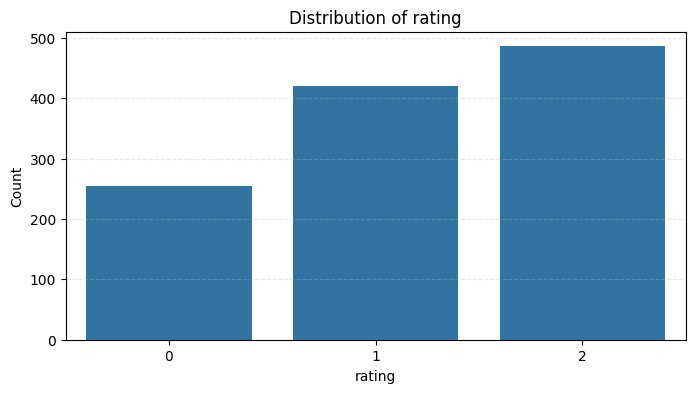

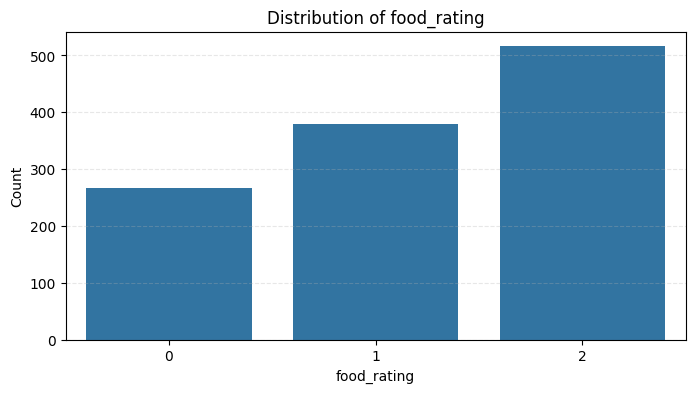

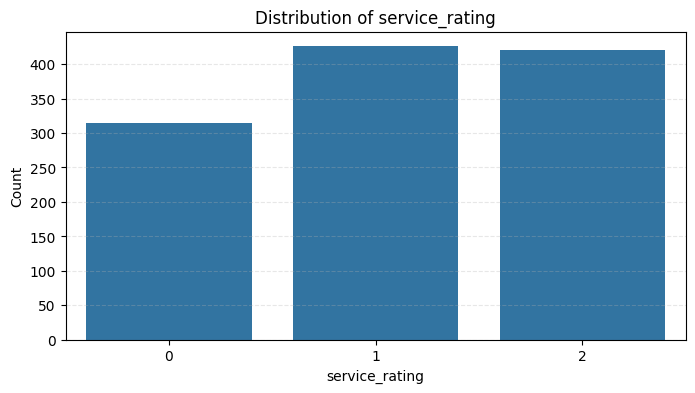

In [14]:
for col in rating_df.columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=rating_df, x=col)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.show()

dari ketiga target output yang didapatkan kesimpulan bahwa data target yang menjadi goal dari project ini aman dan tidak mengalami imbalanced

### Conclussion

dari pemahman yang sudah dilakukan dapat di ambil kesimpulan kalau dataset ini merupakan dataset yang mempunyai output berupa rating, dimana dalam dataset ini terdapat 3 variable penting untuk menilai bagaimana rating dari suatu tempat itu baik atau buruk.


nah dari analisis singkat itu didapat 4 key kunci yaitu :
1. dataset yang digunakan untuk project ini memiliki 1161 data dengan 43 variable
2. dataste ini tidak memiliki nilai null atau missing value 
3. dataset ini belum dataset bersi karena perlu banyak preprorcesisng system  untuk mendapatkan data yang bersih
4. variable yang menjadi target output project ini sudah aman dari tipe data, missing value, dan lain sebagainya

## Exploratory Data analysis

In [15]:
df.dtypes

,0
userID,object
placeID,int64
rating,int64
food_rating,int64
service_rating,int64
latitude_x,float64
longitude_x,float64
the_geom_meter,object
name,object
address,object


In [16]:
object_cols=df.select_dtypes(include='object').columns.tolist()

for col in object_cols:
    print(f"Column: {col}")
    print(df[col].value_counts())
    print("\n")

Column: userID
userID
U1061    18
U1106    18
U1134    16
U1024    15
U1089    14
         ..
U1021     3
U1138     3
U1047     3
U1039     3
U1011     3
Name: count, Length: 138, dtype: int64


Column: the_geom_meter
the_geom_meter
0101000020957F00009F823DA6094858C18A2D4D37F9A44B41    36
0101000020957F00001AD016568C4858C1243261274BA54B41    32
0101000020957F000017D69FF5084858C1A8F2188740A24B41    28
0101000020957F00007768135A174758C155D318CB73A54B41    25
0101000020957F0000B72147F1274858C189A406ED75A34B41    25
                                                      ..
0101000020957F000043A319BA06715AC19443369877554A41     3
0101000020957F0000B21C3F6C5E8557C188ACCF0A444B4941     3
0101000020957F000003B195E25F8457C1C535BD04614B4941     3
0101000020957F0000FC8866CF17785AC14CD7055B02514A41     3
0101000020957F0000A68C31737C725AC1A6E234AE90424A41     3
Name: count, Length: 130, dtype: int64


Column: name
name
Tortas Locas Hipocampo                36
puesto de tacos                       32

## Data Preprocessing

## Baseline Model

## Algorithm Selection

## Model Training and Experiment

## Model Evaluation

## Error Analysis

## Hyperparameter Tuning

## Model Interpretation

## Model saving and Inference

## Conclusion